In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
netflix = pd.read_csv("C:/Users/ASUS/Downloads/netflix_titles.csv")
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [29]:
netflix.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [30]:
netflix.shape

(8807, 12)

In [31]:
netflix.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [32]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [33]:
netflix.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [34]:
netflix.describe(include='object')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [35]:
netflix.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [36]:
netflix.duplicated().sum()

np.int64(0)

In [37]:
netflix['director'] = netflix['director'].fillna("Unknown")
netflix['cast'] = netflix['cast'].fillna("Unknown")
netflix['country'] = netflix['country'].fillna(netflix['country'].mode()[0])
netflix['rating'] = netflix['rating'].fillna(netflix['rating'].mode()[0])
netflix['date_added'] = netflix['date_added'].str.strip()
netflix['date_added'] = pd.to_datetime(netflix['date_added'],errors='coerce')
netflix = netflix.dropna(subset=['date_added'])
netflix['duration'] = netflix['duration'].fillna("Unknown")

In [38]:
netflix.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [39]:
netflix['Year Added'] = netflix['date_added'].dt.year
netflix['Month Added'] = netflix['date_added'].dt.month_name()
netflix['Day Added'] = netflix['date_added'].dt.day_name()

In [40]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Year Added,Month Added,Day Added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September,Saturday
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September,Friday
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September,Friday
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September,Friday
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September,Friday


In [41]:
netflix.shape

(8797, 15)

In [48]:
content_type = netflix['type'].value_counts()
content_type

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

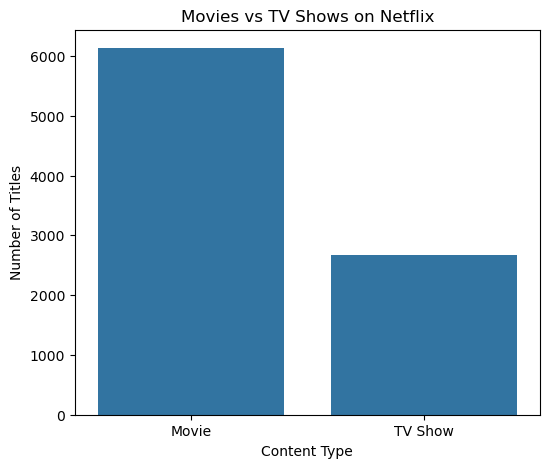

In [49]:
plt.figure(figsize=(6,5))
sns.barplot(
    x=content_type.index,
    y=content_type.values
)
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

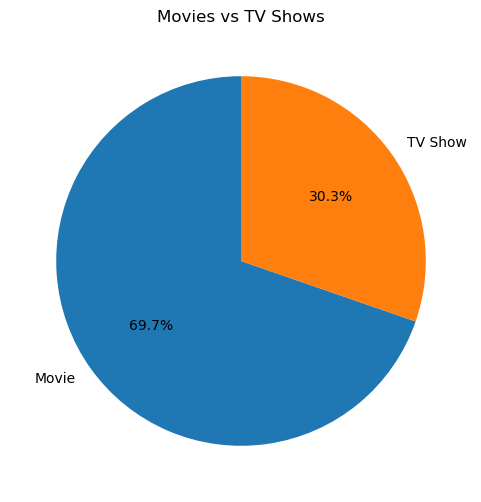

In [42]:
content = netflix['type'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    content,
    labels=content.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Movies vs TV Shows")
plt.show()

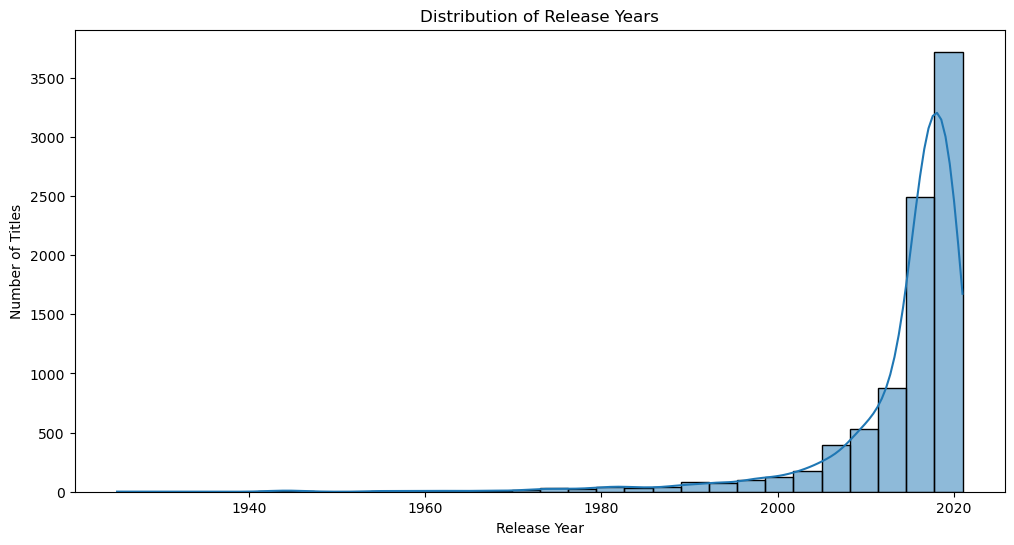

In [43]:
plt.figure(figsize=(12,6))
sns.histplot(
    netflix['release_year'],
    bins=30,
    kde=True
)
plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

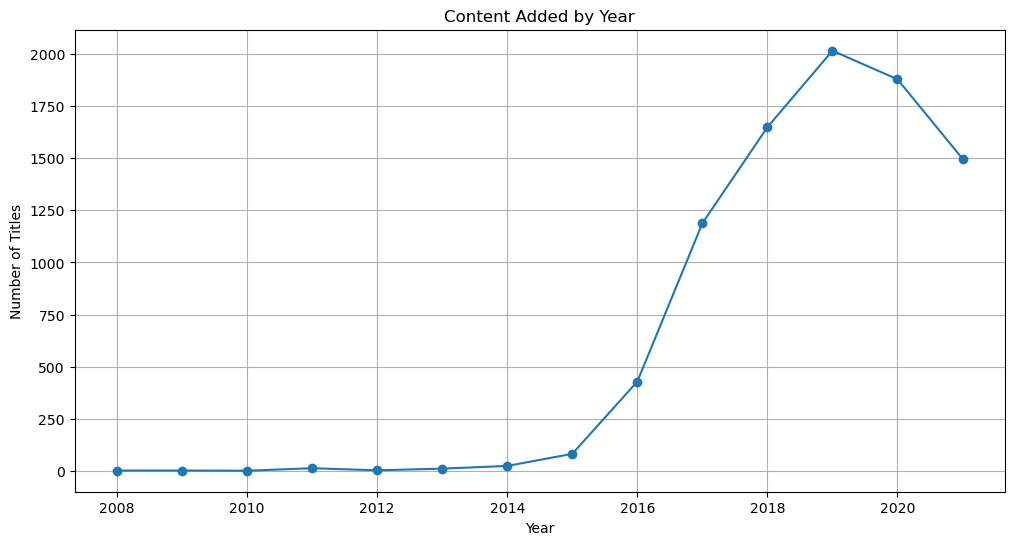

In [50]:
year_added = netflix['Year Added'].value_counts().sort_index()
plt.figure(figsize=(12,6))
plt.plot(
    year_added.index,
    year_added.values,
    marker='o'
)
plt.title("Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

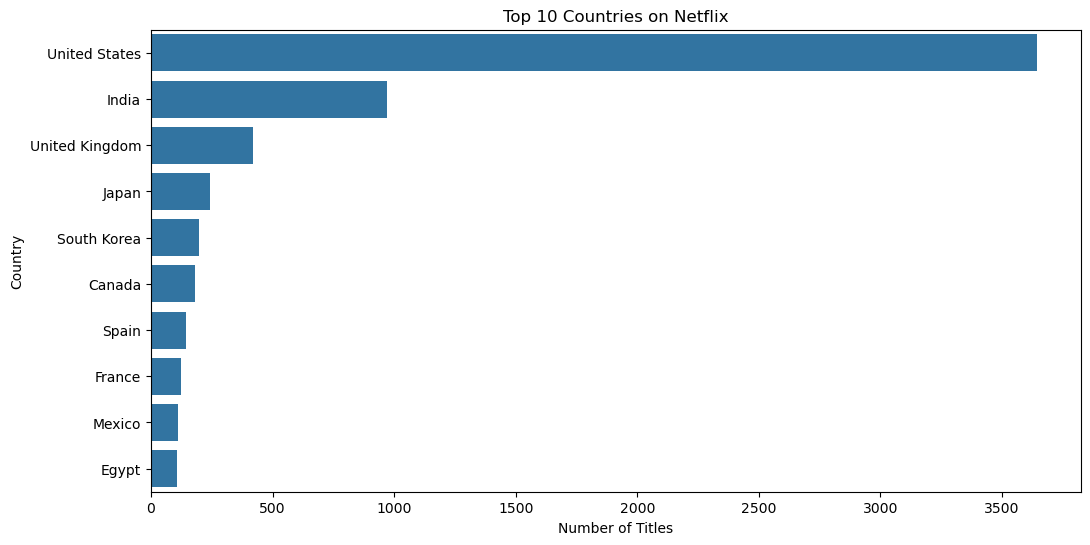

In [44]:
top_country = netflix['country'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_country.values,
    y=top_country.index
)
plt.title("Top 10 Countries on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

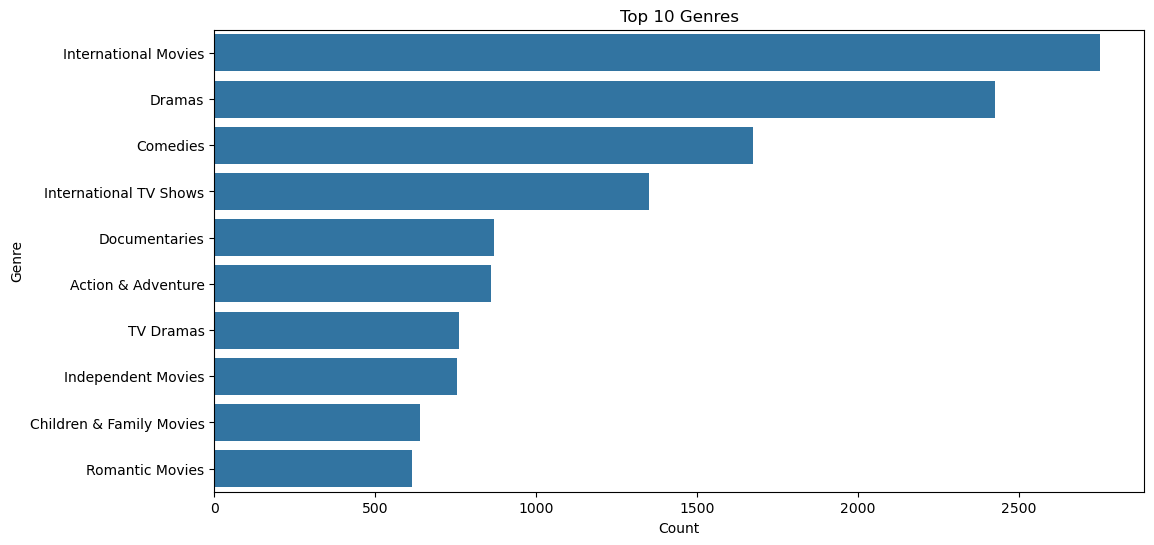

In [52]:
genre = netflix['listed_in'].str.split(',', expand=True).stack()
top_genre = genre.str.strip().value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_genre.values,
    y=top_genre.index
)
plt.title("Top 10 Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

In [54]:
top_countries = netflix['country'].value_counts().head(10).index

In [55]:
country_type = netflix[
    netflix['country'].isin(top_countries)
]
country_type.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Year Added,Month Added,Day Added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September,Saturday
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September,Friday
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September,Friday
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September,Friday
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021,September,Friday


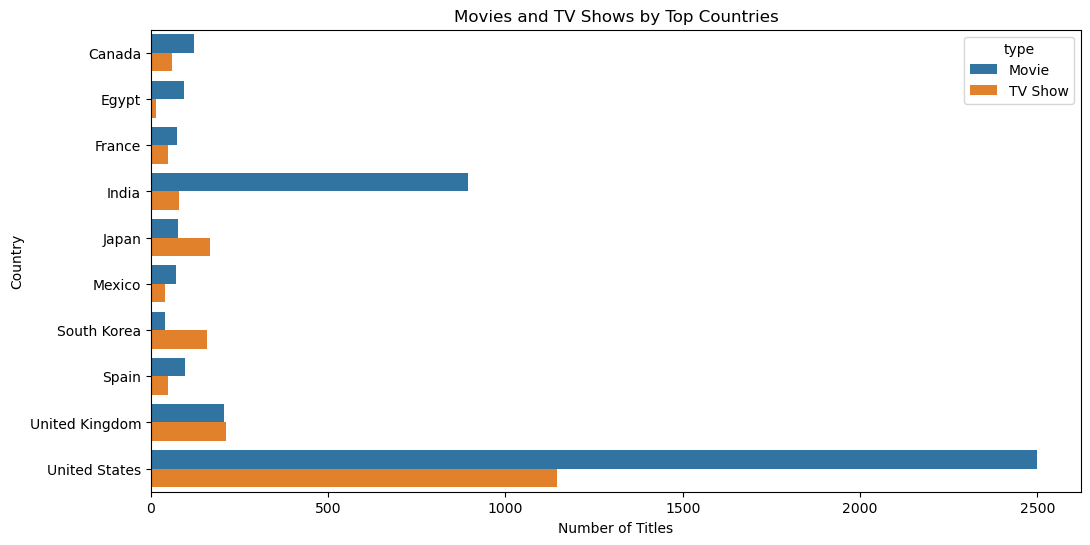

In [56]:
country_analysis = (
    country_type.groupby(['country','type'])
    .size()
    .reset_index(name='count')
)
plt.figure(figsize=(12,6))
sns.barplot(
    data=country_analysis,
    x='count',
    y='country',
    hue='type'
)
plt.title("Movies and TV Shows by Top Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

In [57]:
movies = netflix[
    netflix['type']=="Movie"
].copy()
movies['Minutes'] = (
    movies['duration']
    .str.replace(' min','')
)
movies['Minutes'] = pd.to_numeric(
    movies['Minutes'],
    errors='coerce'
)

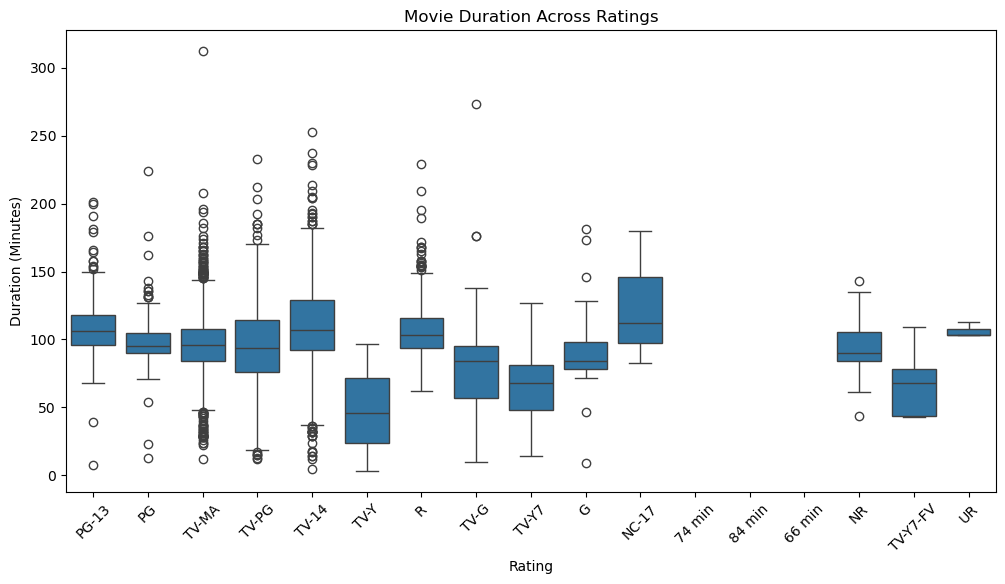

In [58]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=movies,
    x='rating',
    y='Minutes'
)
plt.xticks(rotation=45)
plt.title("Movie Duration Across Ratings")
plt.xlabel("Rating")
plt.ylabel("Duration (Minutes)")
plt.show()

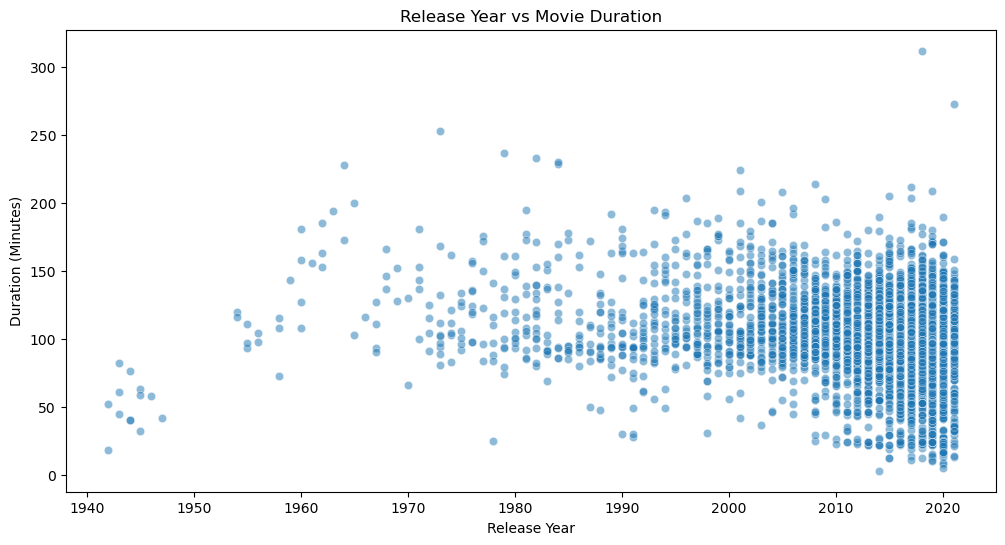

In [59]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=movies,
    x='release_year',
    y='Minutes',
    alpha=0.5
)
plt.title(
    "Release Year vs Movie Duration"
)
plt.xlabel(
    "Release Year"
)
plt.ylabel(
    "Duration (Minutes)"
)
plt.show()

In [61]:
country_rating = (
    netflix.groupby(
        ['country','rating','type']
    )
    .size()
    .reset_index(name='count')
)
country_rating.head()

,country,rating,type,count
0,", France, Algeria",TV-14,Movie,1
1,", South Korea",TV-MA,TV Show,1
2,Argentina,NR,Movie,2
3,Argentina,R,Movie,1
4,Argentina,TV-14,Movie,5


In [62]:
top_countries = (
    netflix['country']
    .value_counts()
    .head(5)
    .index
)
country_rating_top = country_rating[
    country_rating['country'].isin(top_countries)
]

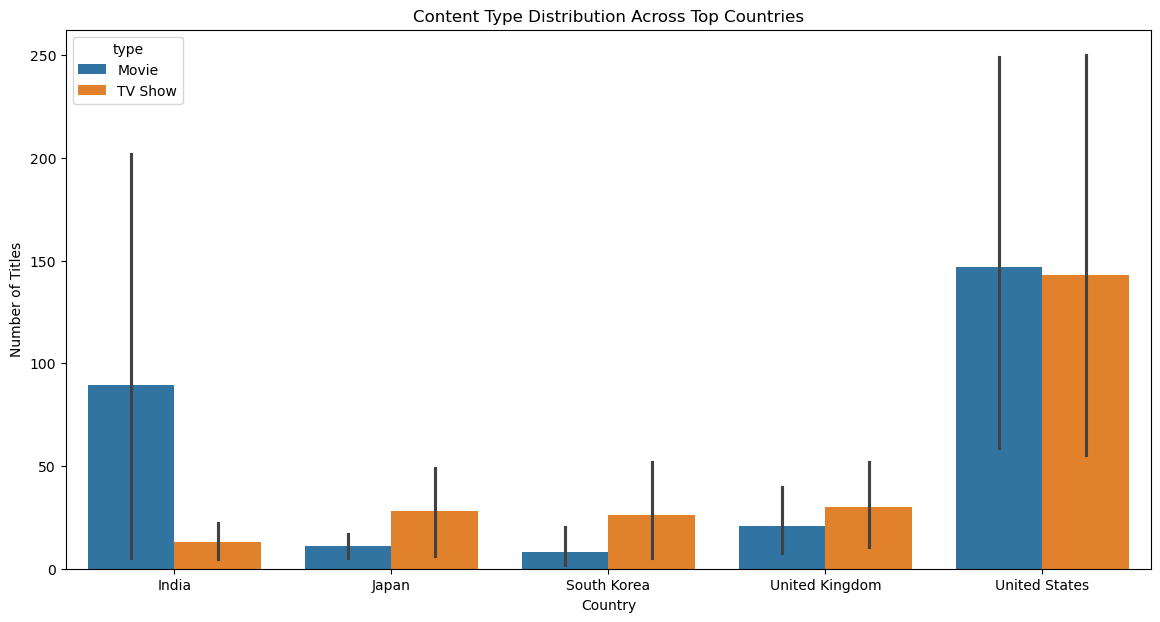

In [63]:
plt.figure(figsize=(14,7))
sns.barplot(
    data=country_rating_top,
    x='country',
    y='count',
    hue='type'
)
plt.title(
    "Content Type Distribution Across Top Countries"
)
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

In [65]:
netflix['country'].value_counts().head(10)

country
United States     3642
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [66]:
netflix['Month Added'].value_counts()

Month Added
July         827
December     813
September    770
April        764
October      760
August       755
March        742
January      738
June         728
November     705
May          632
February     563
Name: count, dtype: int64

In [67]:
netflix['director'].value_counts().head(10)

director
Unknown                   2624
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Martin Scorsese             12
Youssef Chahine             12
Jay Chapman                 12
Name: count, dtype: int64

In [68]:
netflix['rating'].value_counts()

rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [69]:
movies['Minutes'].mean()

np.float64(99.57718668407311)

In [70]:
netflix['Year Added'].value_counts().sort_index()

Year Added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

In [71]:
country_type = (
    netflix.groupby(['country','type'])
    .size()
    .reset_index(name='count')
)

country_type.head()

,country,type,count
0,", France, Algeria",Movie,1
1,", South Korea",TV Show,1
2,Argentina,Movie,38
3,Argentina,TV Show,18
4,"Argentina, Brazil, France, Poland, Germany, De...",Movie,1
